In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [123]:
x, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.990, random_state=42)

In [124]:
df = pd.DataFrame(x, columns=['Feature_1', 'Feature_2'])

In [125]:
df

,Feature_1,Feature_2
0,-5.741847,-7.576254
1,1.969961,1.919418
2,6.807784,1.172954
3,-2.897385,7.565406
4,5.829081,1.569175
...,...,...
495,-5.494265,-5.964722
496,-2.585528,9.352027
497,4.307452,3.625501
498,-7.397123,-5.841590


In [126]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [127]:
inertia = []
K_range = range(1, 11)

In [128]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

In [129]:
inertia

[999.9999999999995,
 312.8552302848986,
 31.001135326569326,
 26.165622847304405,
 22.19082481701238,
 18.594777660564432,
 17.06524250852193,
 15.40983169824129,
 13.639839452852764,
 12.677805505604363]

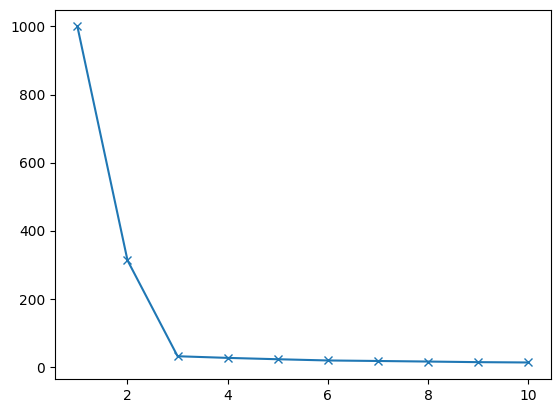

In [130]:
plt.plot(K_range, inertia, marker='x')  # Elbow curve

In [131]:
kmeans_final = KMeans(n_clusters=3, random_state=42)

In [132]:
cluster_labels = kmeans_final.fit_predict(x_scaled)

In [133]:
df['cluster'] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

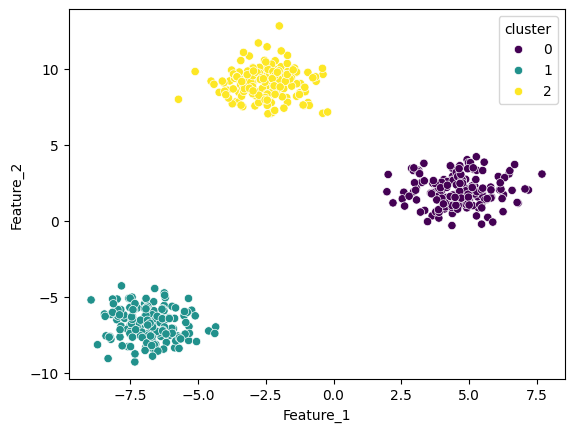

In [134]:
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['cluster'], palette='viridis')

In [135]:
from sklearn.datasets import make_moons

In [163]:
x, y_true = make_moons(n_samples=500, noise=0.07, random_state=42)

In [164]:
from sklearn.cluster import DBSCAN

In [165]:
df = pd.DataFrame(x, columns=['Feature_1', 'Feature_2'])

In [166]:
df

,Feature_1,Feature_2
0,0.830622,-0.432614
1,0.740349,0.825196
2,1.033435,-0.489607
3,-0.293316,0.964066
4,0.308208,1.093364
...,...,...
495,0.243137,0.990493
496,0.088336,0.158634
497,0.557643,-0.333958
498,1.590721,-0.308102


In [167]:
x_scaled = scaler.fit_transform(df)

In [168]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(x_scaled)

In [169]:
df['kmeans_cluster'] = kmeans_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

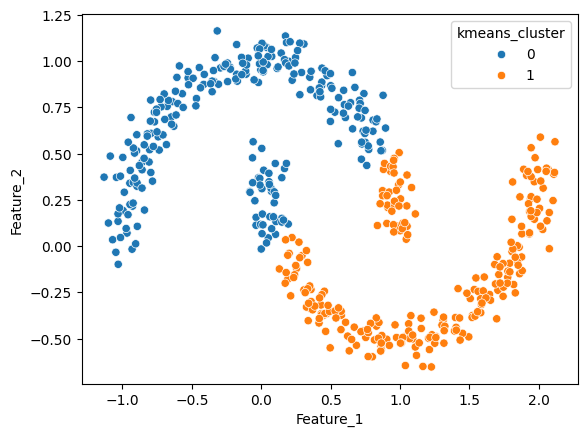

In [170]:
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['kmeans_cluster'], palette='tab10')

In [171]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(x_scaled)

In [172]:
df['dbscan_labels'] = dbscan_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

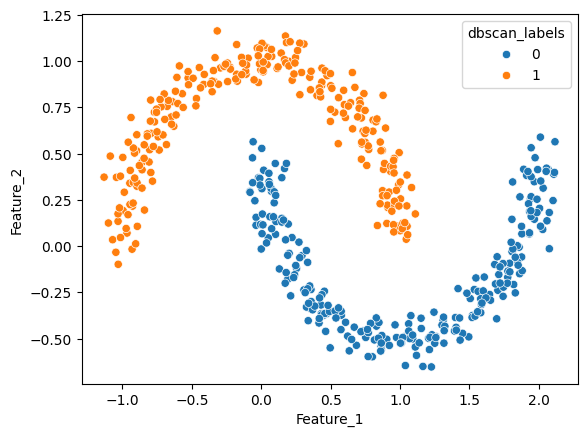

In [173]:
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['dbscan_labels'], palette='tab10')